<a href="https://colab.research.google.com/github/patibandlasaipavan-beep/Supervised_learning_diabetics_identification/blob/model_validation/diabetes_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Understanding the data:

## Columns:
*   **Pregnancies**
*   **Glucose**
*   **BloodPressure**
*   **SkinThickness**
*   **Insulin**
*   **BMI**
*   **DiabetesPedigreeFunction**
*   **Age**
*   **Outcome**

## DiabetesPedigreeFunction:
The DiabetesPedigreeFunction (DPF) is a specialized genetic score used in the dataset to estimate a patient's hereditary risk for diabetes. Instead of just looking at whether a single relative had diabetes, it uses a mathematical formula that factors in how closely related the patient is to family members who have the disease, alongside those relatives' ages.


### Understanding the Scores
*   **Higher Score = Stronger Genetic Link**: A higher value (up to the dataset's maximum of 2.42) indicates a rich family history of diabetes, making the patient genetically more predisposed to developing the condition.
*   **Lower Score = Weaker Genetic Link**: A lower value (down to the dataset's minimum of 0.078) indicates very little to no history of diabetes among close relatives.

## BMI:
BMI is calculated by dividing a person's weight by the square of their height.

## Other columns and their limits:

| Variable            | Lower Limit (Min) | Upper Limit (Max) | Unit     |
| :------------------ | :---------------- | :---------------- | :------- |
| Glucose             | 44                | 199               | mg/dL    |
| Insulin             | 14                | 46                | mu U/mL  |
| BloodPressure       | 24                | 122               | mm Hg    |
| SkinThickness       | 7.0               | 99.0              | mm       |
| BMI                 | 18.2              | 67.1              | kg/m²    |
|Outcome              | 0 (non diabetic) | 1(diabetic)

In [ ]:
import pandas as pd
import numpy as np
import copy
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,precision_score,recall_score,roc_auc_score,f1_score,average_precision_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
import warnings
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
# Load csv data into dataframe. Please ensure 'diabetes.csv' is uploaded to your Colab environment or provide the correct path.
df=pd.read_csv("diabetes.csv")

In [ ]:
#Analyse DATA
print("Top 5 records")
print(df.head())
print("------------------------------------------------------------------------------\n")
print("Data information")
print(df.info())
print("------------------------------------------------------------------------------\n")
print("Data shape")
print(df.shape)
print("------------------------------------------------------------------------------\n")
print("Null values")
print(df.isna().sum())
print("------------------------------------------------------------------------------\n")
print("Duplicate values")
print(df.duplicated().sum())
print("------------------------------------------------------------------------------\n")
print("Data description")
df.describe()


Top 5 records
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  
------------------------------------------------------------------------------

Data information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


From Data Description, it is evident that there are no null or duplicate records but Glucose, Blood pressure, skinthickness, Insulin and BMI columns minumum values are zero which is either because of human error or missed vaules.

These zero value records should be treated by replacing by null value rather the deletion of records to avoid data loss.

In [ ]:
#Take copy of dataframe
df_non_zero =copy.deepcopy(df)
#replace zero columns to null values

df_non_zero[non_zero_columns]=np.where(df_non_zero[non_zero_columns]<=0,np.nan,df_non_zero[non_zero_columns])
print(df_non_zero.isna().sum())


Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


Below columns has high number of null values:

SkinThickness         -      227

Insulin       -              374

Outcome
0    500
1    268
Name: count, dtype: int64


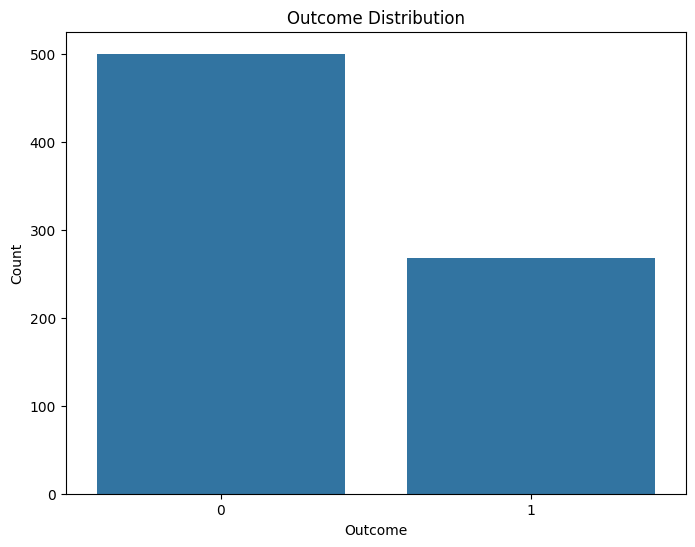

In [ ]:
#Diabetes Outcome Distribution
print(df_non_zero['Outcome'].value_counts())
#plot outome distribution with count
plt.figure(figsize=(8,6))
sns.countplot(x='Outcome',data=df_non_zero,stat="count")
plt.xlabel('Outcome')
plt.ylabel('Count')
plt.title('Outcome Distribution')
plt.show()

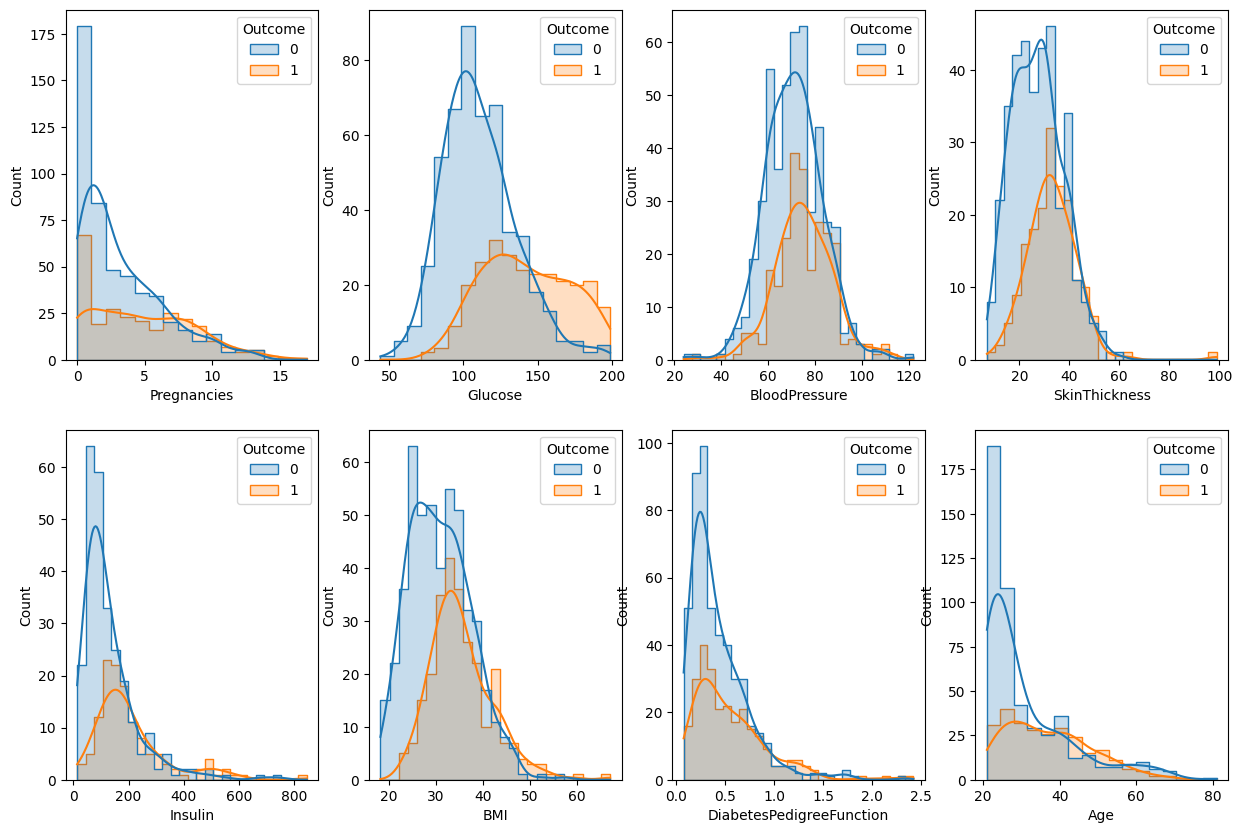

In [ ]:
#feature Distibution - histogram plot

feature_columns=["Pregnancies","Glucose","BloodPressure","SkinThickness","Insulin","BMI","DiabetesPedigreeFunction","Age"]
figure,axes = plt.subplots(nrows=2,ncols=4,figsize=(15,10))
axes=axes.flatten()
for column,ax in zip(feature_columns,axes):
    sns.histplot(x=column,data=df_non_zero,ax=ax,hue=df_non_zero['Outcome'],element='step',kde=True)
    plt.show


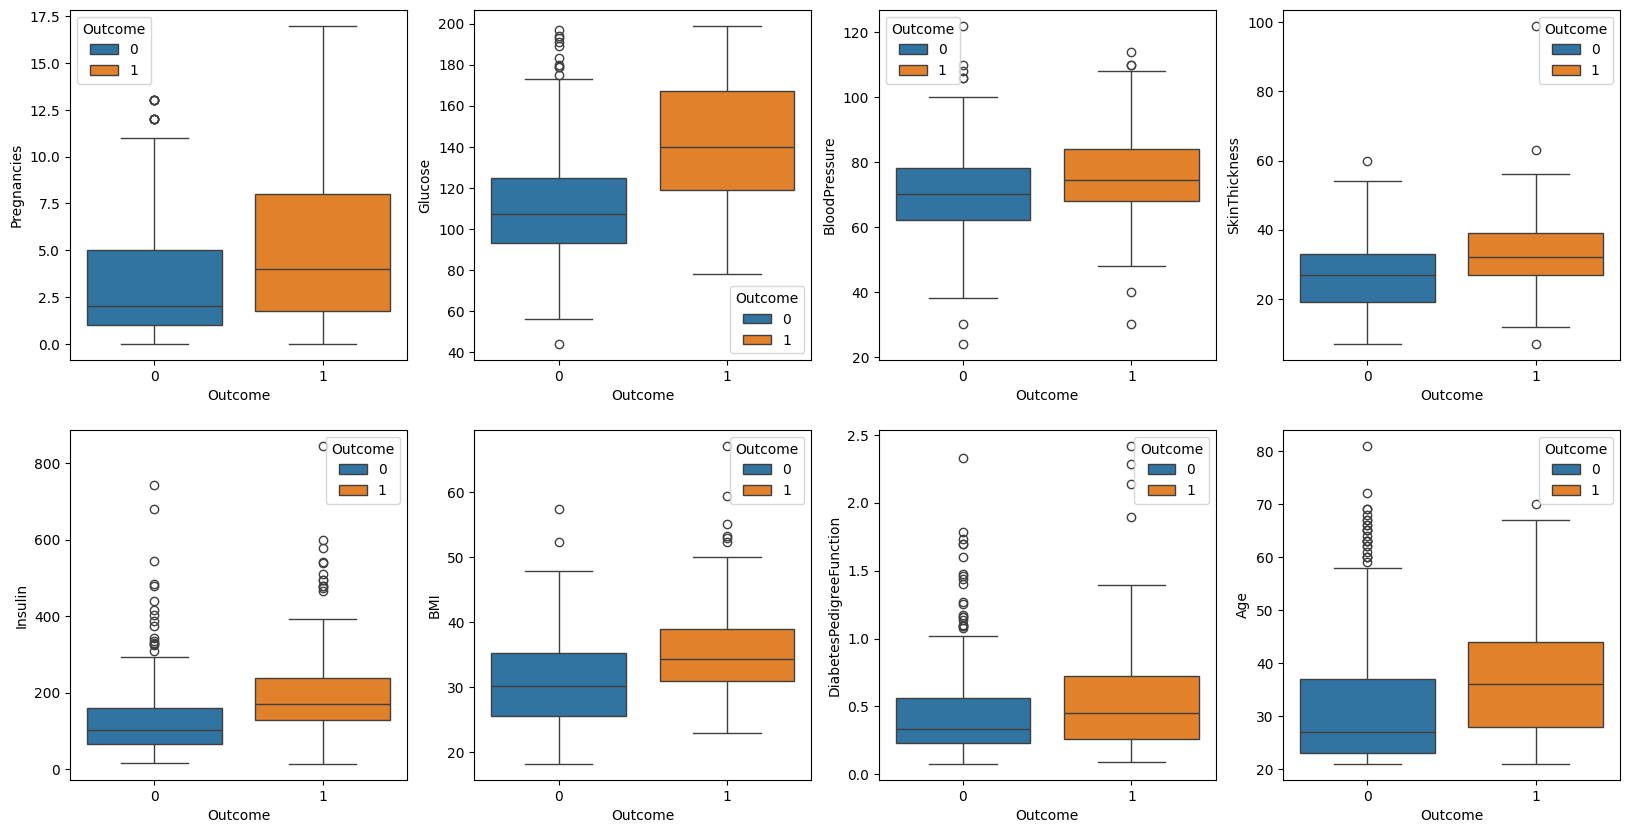

In [ ]:
#As feature distribution is skewed with outliers, lets box plot wrt to outcome
figure,axes = plt.subplots(nrows=2,ncols=4,figsize=(20,10))
axes=axes.flatten()
for column,ax in zip(feature_columns,axes):
    sns.boxplot(x='Outcome',y=column,data=df_non_zero,ax=ax,hue=df_non_zero['Outcome'])
    plt.show


In [ ]:

#build outlier report
for column in feature_columns:
  values= df_non_zero[column].dropna()
  first_quartile,third_quartile=np.percentile(values,[25,75])
  iqr=third_quartile-first_quartile
  lower_bound=first_quartile-(1.5*iqr)
  upper_bound=third_quartile+(1.5*iqr)
  count = ((values < lower_bound) | (values > upper_bound)).sum()
  print(f"{column} has {count} outliers. lower bound is {round(lower_bound,3)} and upper bound is {round(upper_bound,3)}")
#

Pregnancies has 4 outliers. lower bound is -6.5 and upper bound is 13.5
Glucose has 0 outliers. lower bound is 36.0 and upper bound is 204.0
BloodPressure has 14 outliers. lower bound is 40.0 and upper bound is 104.0
SkinThickness has 3 outliers. lower bound is 1.0 and upper bound is 57.0
Insulin has 24 outliers. lower bound is -94.375 and upper bound is 360.625
BMI has 8 outliers. lower bound is 13.85 and upper bound is 50.25
DiabetesPedigreeFunction has 29 outliers. lower bound is -0.33 and upper bound is 1.2
Age has 9 outliers. lower bound is -1.5 and upper bound is 66.5


# Outliers Report

Pregnancies has 4 outliers.

Glucose has 0 outliers.

BloodPressure has 14 outliers.

SkinThickness has 3 outliers.

Insulin has 24 outliers.

BMI has 8 outliers.

DiabetesPedigreeFunction has 29 outliers.

Age has 9 outliers.

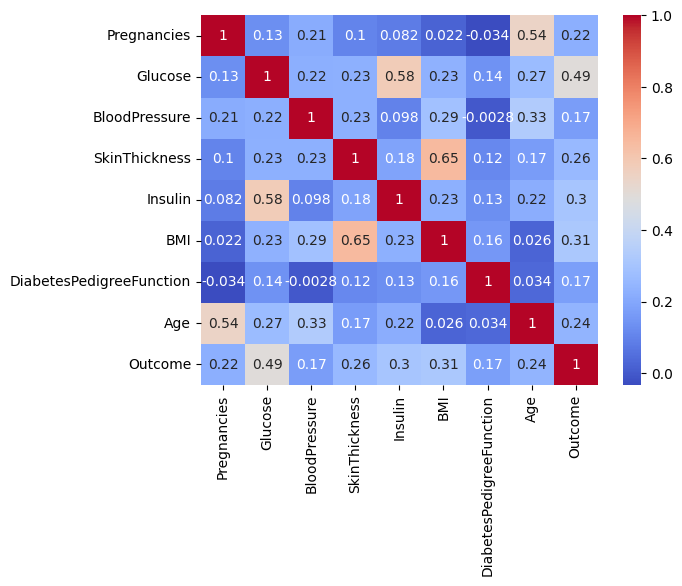

In [ ]:
#feature correlation matrix
corr_matrix=df_non_zero.corr()
sns.heatmap(corr_matrix,annot=True,cmap='coolwarm')
plt.show()

From correction matrix,

 It is found that Glucose(0.49),BMI(0.31),skinThichness(0.26) has good positive correction to Outcome

## Exploratory Data Analysis (EDA) Summary

### 1. Data Overview
*   **Dimensions**: The dataset contains 768 records and 9 features.
*   **Missing Values**: Initially, no explicit missing values were present. However, after replacing biologically implausible zero values (in 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI') with NaN, we observed significant missing values, particularly in 'Insulin' (374) and 'SkinThickness' (227).
*   **Duplicates**: No duplicate records were found.

### 2. Outcome Distribution
*   The `Outcome` variable shows an imbalance: 500 individuals are non-diabetic (0) and 268 are diabetic (1). This imbalance will need to be considered during model training.

### 3. Feature Distributions and Outliers
*   **Skewness**: Most numerical features exhibit a right-skewed distribution, indicating a concentration of values at the lower end with a tail extending towards higher values.
*   **Outliers**: Several features contain outliers, as identified by the box plots and the outlier report. Notably:
    *   `Pregnancies`: 4 outliers.
    *   `BloodPressure`: 14 outliers.
    *   `Insulin`: 24 outliers (highest among the features).
    *   `BMI`: 8 outliers.
    *   `DiabetesPedigreeFunction`: 29 outliers.
    *   `Age`: 9 outliers.
*   **Impact on Outcome**: Box plots comparing features against the `Outcome` variable suggest that higher values in `Glucose`, `BMI`, `Age`, and `DiabetesPedigreeFunction` tend to be associated with a positive diabetes outcome (1).

### 4. Feature Correlation
*   The correlation matrix reveals the following strong positive correlations with the `Outcome` variable:
    *   `Glucose`: 0.49
    *   `BMI`: 0.31
    *   `SkinThickness`: 0.26
*   `Pregnancies` and `Age` also show moderate positive correlations with `Outcome` (0.22 and 0.24 respectively). These features are likely strong predictors for diabetes.

AS Dataset is small, outlier can represent rare or uncertain cases, Hence Outlier will not be removed.

In [ ]:
df_non_zero.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,763.000000,733.000000,541.000000,394.000000,757.000000,768.000000,768.000000,768.000000
mean,3.845052,121.686763,72.405184,29.153420,155.548223,32.457464,0.471876,33.240885,0.348958
std,3.369578,30.535641,12.382158,10.476982,118.775855,6.924988,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,64.000000,22.000000,76.250000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,29.000000,125.000000,32.300000,0.372500,29.000000,0.000000
75%,6.000000,141.000000,80.000000,36.000000,190.000000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


Split Train and Test data in 20:80 ratio with Stratified sampling.

In [ ]:


#Split Train and Test data in 20:80 ratio with Stratified sampling
df_final_data= copy.deepcopy(df)
X=df_final_data.drop('Outcome',axis=1)
y=df_final_data['Outcome']
train_test_split_ratio=0.2
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=train_test_split_ratio,stratify=y,random_state=42)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(614, 8)
(154, 8)
(614,)
(154,)


In [ ]:
non_zero_columns=["Glucose","BloodPressure","SkinThickness","Insulin","BMI","Age"]
all_features=["Pregnancies","Glucose","BloodPressure","SkinThickness","Insulin","BMI","DiabetesPedigreeFunction","Age"]
#Replace non zero values with median
indicator_columns=["Insulin","SkinThickness"]
for feature in indicator_columns:
   X_test[feature+"_missing"]=(X_test[feature]==0 | X_test[feature].isna()).astype(int)
   X_train[feature+"_missing"]=(X_train[feature]==0 | X_train[feature].isna()).astype(int)

X_train[non_zero_columns]= X_train[non_zero_columns].replace(0,np.nan)
X_test[non_zero_columns]= X_test[non_zero_columns].replace(0,np.nan)
print(X_test.describe())
#impute null values with median
imputer = SimpleImputer(strategy='median')
X_train[non_zero_columns]=imputer.fit_transform(X_train[non_zero_columns])
X_test[non_zero_columns]=imputer.transform(X_test[non_zero_columns])
X_test.describe()


       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   154.000000  153.000000     142.000000     102.000000   70.000000   
mean      3.948052  121.627451      73.485915      29.558824  185.500000   
std       3.591552   32.317887      11.807400      10.334575  159.423395   
min       0.000000   44.000000      48.000000      10.000000   14.000000   
25%       1.000000  100.000000      65.250000      22.250000   83.500000   
50%       3.000000  118.000000      72.000000      29.000000  123.500000   
75%       6.000000  142.000000      81.500000      36.750000  262.500000   
max      15.000000  197.000000     106.000000      63.000000  846.000000   

              BMI  DiabetesPedigreeFunction         Age  Insulin_missing  \
count  152.000000                154.000000  154.000000       154.000000   
mean    32.491447                  0.449740   32.740260         0.545455   
std      7.144469                  0.335567   11.487877         0.499554   
min     18.

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Insulin_missing,SkinThickness_missing
count,154.000000,154.000000,154.000000,154.000000,154.000000,154.000000,154.000000,154.000000,154.000000,154.000000
mean,3.948052,121.597403,73.370130,29.370130,152.500000,32.490260,0.449740,32.740260,0.545455,0.337662
std,3.591552,32.214258,11.341952,8.400865,111.245078,7.097627,0.335567,11.487877,0.499554,0.474456
min,0.000000,44.000000,48.000000,10.000000,14.000000,18.200000,0.078000,21.000000,0.000000,0.000000
25%,1.000000,100.000000,66.000000,25.000000,125.000000,26.600000,0.237000,23.000000,0.000000,0.000000
50%,3.000000,117.500000,72.000000,29.000000,125.000000,32.000000,0.333000,28.000000,1.000000,0.000000
75%,6.000000,141.500000,80.000000,32.000000,125.000000,36.600000,0.583000,39.750000,1.000000,1.000000
max,15.000000,197.000000,106.000000,63.000000,846.000000,59.400000,2.420000,68.000000,1.000000,1.000000


As Insulin has 25 null values and reasonable correlation with Glucodse. new feature without insulin is consider for model training and validation

In [ ]:
#filter different features to model data

without_insulin_test = X_test.drop('Insulin', axis=1).drop('Insulin_missing',axis=1)
without_insulin_train = X_train.drop('Insulin', axis=1).drop('Insulin_missing',axis=1)
without_insulin_skinThichness_test = without_insulin_test.drop('SkinThickness', axis=1).drop('SkinThickness_missing',axis=1)
without_insulin_skinThichness_train = without_insulin_train.drop('SkinThickness', axis=1).drop('SkinThickness_missing',axis=1)
all_feature_insulin_indicator_test = X_test.copy()
all_feature_insulin_indicator_train = X_train.copy()
print(all_feature_insulin_indicator_train.describe())

       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   614.000000  614.000000     614.000000     614.000000  614.000000   
mean      3.819218  121.671010      72.140065      29.042345  137.705212   
std       3.314148   30.003794      12.275119       8.891855   78.764767   
min       0.000000   56.000000      24.000000       7.000000   15.000000   
25%       1.000000   99.000000      64.000000      25.000000  120.000000   
50%       3.000000  117.000000      72.000000      29.000000  125.000000   
75%       6.000000  140.000000      80.000000      32.000000  130.000000   
max      17.000000  199.000000     122.000000      99.000000  744.000000   

              BMI  DiabetesPedigreeFunction         Age  Insulin_missing  \
count  614.000000                614.000000  614.000000       614.000000   
mean    32.448208                  0.477428   33.366450         0.472313   
std      6.824122                  0.330300   11.833438         0.499640   
min     18.

In [ ]:
def scaler_fit(X_train,X_test):
  scaler=StandardScaler()
  X_train_scaled=scaler.fit_transform(X_train)
  X_test_scaled=scaler.transform(X_test)
  return X_train_scaled,X_test_scaled


In [ ]:
def model_fit(X_train,X_test,y_train,y_test,model_type):
  #Fit with logistic regression
  if 'logistic' in model_type:
      model=LogisticRegression()
  elif 'knn' in model_type:
      model=KNeighborsClassifier(n_neighbors=5)
  elif 'decision_tree' in model_type:
      model=DecisionTreeClassifier( max_depth=6,min_samples_leaf=5, random_state=42)
  elif 'random_forest' in model_type:
      model=RandomForestClassifier(n_estimators=100,random_state=42,max_depth=8,min_samples_leaf=5,n_jobs=1)
  elif 'svm' in model_type:
      model=SVC(probability=True)
  model.fit(X_train,y_train)
  y_pred=model.predict(X_test)
  y_pred_prob= model.predict_proba(X_test)[:,1]
  return y_pred,y_pred_prob

In [ ]:
#model validations
def model_validation(y_test,y_pred,y_pred_prob,model):
  true_negative,false_positive,false_negative,true_positive=confusion_matrix(y_test,y_pred,labels=[0,1]).ravel()
  metrics : dict[str,float| int]= {
      "accuracy": float( accuracy_score(y_test,y_pred)),
      "precision": float(precision_score(y_test,y_pred)),
      "recall": float(recall_score(y_test,y_pred)),
      "roc_auc":float(roc_auc_score(y_test,y_pred_prob)),
      "f1":float(f1_score(y_test,y_pred)),
      "true_negative":int(true_negative),
      "false_positive":int(false_positive),
      "false_negative":int(false_negative),
      "true_positive":int(true_positive),
      }
  print(model+"\n")

  for key in metrics:
     print(f" {key} : {metrics[key]:.2f}")
  print("-----------------------------------------------------------------------")
  return metrics

In [ ]:
def train_test_validate(X_train,X_test,y_train,y_test,model):
  if 'logistic' in model or 'knn' in  model:
    x_scaled_train,x_scaled_test=scaler_fit(X_train,X_test)
  else:
    x_scaled_train,x_scaled_test=X_train,X_test
  y_pred,y_pred_prob=model_fit(x_scaled_train,x_scaled_test,y_train,y_test,model)
  return model_validation(y_test,y_pred,y_pred_prob,model)

In [ ]:
model_type : dict[str,dict[str,float|int]] = {
    "without_insulin_logistic":train_test_validate(without_insulin_train,without_insulin_test,y_train,y_test,"without_insulin_logistic"),
    "without_insulin_skinThichness_logistic":train_test_validate(without_insulin_skinThichness_train,without_insulin_skinThichness_test,y_train,y_test,"without_insulin_skinThichness_logistic"),
    "all_feature_insulin_indicator_logistic":train_test_validate(all_feature_insulin_indicator_train,all_feature_insulin_indicator_test,y_train,y_test,"all_feature_insulin_indicator_logistic"),
    "without_insulin_knn":train_test_validate(without_insulin_train,without_insulin_test,y_train,y_test,"without_insulin_knn"),
    "without_insulin_skinThichness_knn":train_test_validate(without_insulin_skinThichness_train,without_insulin_skinThichness_test,y_train,y_test,"without_insulin_skinThichness_knn"),
    "all_feature_insulin_indicator_knn":train_test_validate(all_feature_insulin_indicator_train,all_feature_insulin_indicator_test,y_train,y_test,"all_feature_insulin_indicator_knn"),
    "without_insulin_decision_tree":train_test_validate(without_insulin_train,without_insulin_test,y_train,y_test,"without_insulin_decision_tree"),
    "without_insulin_skinThichness_decision_tree":train_test_validate(without_insulin_skinThichness_train,without_insulin_skinThichness_test,y_train,y_test,"without_insulin_skinThichness_decision_tree"),
    "all_feature_insulin_indicator_decision_tree":train_test_validate(all_feature_insulin_indicator_train,all_feature_insulin_indicator_test,y_train,y_test,"all_feature_insulin_indicator_decision_tree"),
    "without_insulin_random_forest":train_test_validate(without_insulin_train,without_insulin_test,y_train,y_test,"without_insulin_random_forest"),
    "without_insulin_skinThichness_random_forest":train_test_validate(without_insulin_skinThichness_train,without_insulin_skinThichness_test,y_train,y_test,"without_insulin__skinThichness_random_forest"),
    "all_feature_insulin_indicator_random_forest":train_test_validate(all_feature_insulin_indicator_train,all_feature_insulin_indicator_test,y_train,y_test,"all_feature_insulin_indicator_random_forest"),
    "without_insulin_svm":train_test_validate(without_insulin_train,without_insulin_test,y_train,y_test,"without_insulin_svm"),
    "without_insulin_skinThichness_svm":train_test_validate(without_insulin_skinThichness_train,without_insulin_skinThichness_test,y_train,y_test,"without_insulin_skinThichness_svm"),
    "all_feature_insulin_indicator_svm":train_test_validate(all_feature_insulin_indicator_train,all_feature_insulin_indicator_test,y_train,y_test,"all_feature_insulin_indicator_svm"),
}

without_insulin_logistic

 accuracy : 0.70
 precision : 0.59
 recall : 0.48
 roc_auc : 0.82
 f1 : 0.53
 true_negative : 82.00
 false_positive : 18.00
 false_negative : 28.00
 true_positive : 26.00
-----------------------------------------------------------------------
without_insulin_skinThichness_logistic

 accuracy : 0.70
 precision : 0.59
 recall : 0.48
 roc_auc : 0.81
 f1 : 0.53
 true_negative : 82.00
 false_positive : 18.00
 false_negative : 28.00
 true_positive : 26.00
-----------------------------------------------------------------------
all_feature_insulin_indicator_logistic

 accuracy : 0.69
 precision : 0.57
 recall : 0.52
 roc_auc : 0.82
 f1 : 0.54
 true_negative : 79.00
 false_positive : 21.00
 false_negative : 26.00
 true_positive : 28.00
-----------------------------------------------------------------------
without_insulin_knn

 accuracy : 0.70
 precision : 0.58
 recall : 0.52
 roc_auc : 0.77
 f1 : 0.55
 true_negative : 80.00
 false_positive : 20.00
 false_negative : 26

--- Model Performance Comparison (Sorted by F1-Score) ---


,accuracy,precision,recall,f1,roc_auc
without_insulin_skinThichness_random_forest,0.753247,0.666667,0.592593,0.627451,0.820185
without_insulin_random_forest,0.759740,0.697674,0.555556,0.618557,0.821481
all_feature_insulin_indicator_random_forest,0.753247,0.681818,0.555556,0.612245,0.820741
without_insulin_skinThichness_knn,0.733766,0.632653,0.574074,0.601942,0.758889
all_feature_insulin_indicator_knn,0.714286,0.592593,0.592593,0.592593,0.770833
all_feature_insulin_indicator_decision_tree,0.733766,0.675676,0.462963,0.549451,0.824444
without_insulin_knn,0.701299,0.583333,0.518519,0.549020,0.771204
all_feature_insulin_indicator_logistic,0.694805,0.571429,0.518519,0.543689,0.816296
without_insulin_skinThichness_svm,0.727273,0.657895,0.462963,0.543478,0.791481
without_insulin_decision_tree,0.720779,0.641026,0.462963,0.537634,0.810741


/tmp/ipykernel_1548/2438708489.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=results_df.index, y=results_df['f1'], palette='viridis')


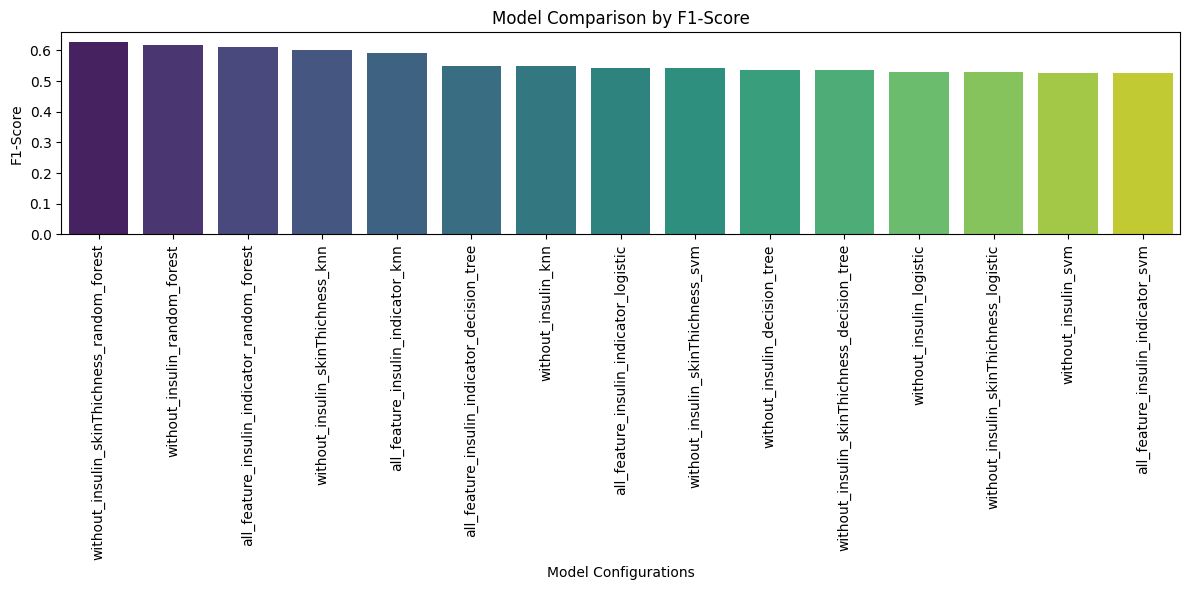

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Convert the model_type results dictionary into a clean pandas DataFrame
results_df = pd.DataFrame(model_type).T

# Sort models based on key performance metrics (F1-score, ROC AUC, and Accuracy)
results_df = results_df.sort_values(by=['f1', 'roc_auc', 'accuracy'], ascending=False)

print("--- Model Performance Comparison (Sorted by F1-Score) ---")
display(results_df[['accuracy', 'precision', 'recall', 'f1', 'roc_auc']])

# Visualize the top performing models
plt.figure(figsize=(12, 6))
sns.barplot(x=results_df.index, y=results_df['f1'], palette='viridis')
plt.xticks(rotation=90)
plt.title('Model Comparison by F1-Score')
plt.ylabel('F1-Score')
plt.xlabel('Model Configurations')
plt.tight_layout()
plt.show()

### Recommendation Analysis:

Based on the printed output of your model validations:

1. **Best Overall Performer: Random Forest**
   * **`without_insulin_skinThichness_random_forest`** achieves an **F1-Score of 0.63** and a high **ROC AUC of 0.82**, along with an **Accuracy of 75%**.
   * **`without_insulin_random_forest`** is also exceptional with an **F1-Score of 0.62**, **ROC AUC of 0.82**, and the highest overall **Accuracy of 76%**.

2. **Why Random Forest is Preferred here:**
   * **Handling Imbalance:** Since your dataset has an imbalanced outcome (more non-diabetic than diabetic patients), standard accuracy can be misleading. The F1-score balances Precision (minimizing false positives) and Recall (minimizing missed diabetic cases). Random Forest consistently maintains the highest F1-scores here.
   * **Feature Robustness:** Excluding high-null features like `Insulin` and `SkinThickness` (`without_insulin_skinThichness_random_forest`) prevents the model from relying on heavily imputed median data, which leads to better generalizability without losing model performance.

In [ ]:
# #plot confusion matrix
# plt.figure(figsize=(8,6))
# sns.heatmap(confusion,annot=True,fmt='d',cmap='Blues',xticklabels=['Non-Diabetic','Diabetic'],yticklabels=['Diabetic','Non-Diabetic'])
# plt.xlabel('Predicted')
# plt.ylabel('Actual')
# plt.title('Confusion Matrix')
# plt.show()
